## 1. Setup

In [1]:
import sys
!{sys.executable} -m pip install -q tensorflow kagglehub matplotlib numpy pillow scikit-learn


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import sys
!{sys.executable} -m pip install -q matplotlib


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import sys
print(sys.version)
print(sys.executable)

3.12.10 (tags/v3.12.10:0cc8128, Apr  8 2025, 12:21:36) [MSC v.1943 64 bit (AMD64)]
c:\Users\abhay\AppData\Local\Programs\Python\Python312\python.exe


In [5]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import kagglehub
from sklearn.metrics import classification_report, confusion_matrix



print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.21.0
GPU available: []


## 2. Download and locate the dataset


In [6]:
path = kagglehub.dataset_download("tongpython/cat-and-dog")
print("Dataset downloaded to:", path)

Dataset downloaded to: C:\Users\abhay\.cache\kagglehub\datasets\tongpython\cat-and-dog\versions\1


In [7]:
train_dir, test_dir = None, None

for root, dirs, files in os.walk(path):
    if "cats" in dirs and "dogs" in dirs:
        if "training" in root.lower():
            train_dir = root
        elif "test" in root.lower():
            test_dir = root

print("Training directory:", train_dir)
print("Test directory:", test_dir)

Training directory: C:\Users\abhay\.cache\kagglehub\datasets\tongpython\cat-and-dog\versions\1\training_set\training_set
Test directory: C:\Users\abhay\.cache\kagglehub\datasets\tongpython\cat-and-dog\versions\1\test_set\test_set


In [8]:
for name, folder in [("train", train_dir), ("test", test_dir)]:
    print(f"{name} classes:", os.listdir(folder))
    for class_name in ["cats", "dogs"]:
        class_folder = os.path.join(folder, class_name)
        count = len([f for f in os.listdir(class_folder)
                     if f.lower().endswith((".jpg", ".jpeg", ".png"))])
        print(f"  {class_name}: {count}")

train classes: ['cats', 'dogs']
  cats: 4000
  dogs: 4005
test classes: ['cats', 'dogs']
  cats: 1011
  dogs: 1012


## 3. Config

In [9]:
IMG_SIZE = (160, 160)   # MobileNetV2's native input size — better transfer than 128x128
BATCH_SIZE = 32
SEED = 42

## 4. Build datasets

We split the **training** folder into train (80%) and validation (20%). The **test**
folder is kept completely separate and is only touched once, at the very end, for the
final accuracy number — this gives you an honest measure of real-world performance.

In [10]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=False,
)

class_names = train_ds.class_names
print("Classes:", class_names)

Found 8005 files belonging to 2 classes.
Using 6404 files for training.
Found 8005 files belonging to 2 classes.
Using 1601 files for validation.
Found 2023 files belonging to 2 classes.
Classes: ['cats', 'dogs']


In [11]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

## 5. Data augmentation

Applied only during training (it's a no-op at inference/evaluation time). This is what
stops the model from just memorizing the ~8,000 training images.

In [12]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.15),
    tf.keras.layers.RandomZoom(0.15),
    tf.keras.layers.RandomContrast(0.1),
], name="data_augmentation")

## 6. Build the model — MobileNetV2 transfer learning

`preprocess_input` for MobileNetV2 scales pixels to [-1, 1] (not the same as the simple
`Rescaling(1/255)` your original model used) — using the wrong preprocessing for a
pretrained network is a common reason transfer learning underperforms, so we use the
matching one here.

In [13]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=IMG_SIZE + (3,),
    include_top=False,
    weights="imagenet",
)
base_model.trainable = False  # freeze for phase 1

inputs = tf.keras.Input(shape=IMG_SIZE + (3,))
x = data_augmentation(inputs)
x = tf.keras.applications.mobilenet_v2.preprocess_input(x)
x = base_model(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.3)(x)
outputs = tf.keras.layers.Dense(1, activation="sigmoid")(x)

model = tf.keras.Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_160            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## 7. Phase 1 — train the classification head

The pretrained base is frozen; only the new top layers learn. `EarlyStopping` restores
the best weights automatically instead of relying on a fixed epoch count, and
`ReduceLROnPlateau` lowers the learning rate if validation loss stalls.

In [16]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=4, restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6
    ),
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=callbacks,
)

Epoch 1/10
201/201 ━━━━━━━━━━━━━━━━━━━━ 118s 585ms/step - accuracy: 0.9140 - loss: 0.2062 - val_accuracy: 0.9738 - val_loss: 0.0753 - learning_rate: 0.0010
Epoch 2/10
201/201 ━━━━━━━━━━━━━━━━━━━━ 116s 577ms/step - accuracy: 0.9474 - loss: 0.1348 - val_accuracy: 0.9806 - val_loss: 0.0574 - learning_rate: 0.0010
Epoch 3/10
201/201 ━━━━━━━━━━━━━━━━━━━━ 112s 558ms/step - accuracy: 0.9510 - loss: 0.1240 - val_accuracy: 0.9800 - val_loss: 0.0510 - learning_rate: 0.0010
Epoch 4/10
201/201 ━━━━━━━━━━━━━━━━━━━━ 123s 611ms/step - accuracy: 0.9508 - loss: 0.1220 - val_accuracy: 0.9825 - val_loss: 0.0476 - learning_rate: 0.0010
Epoch 5/10
201/201 ━━━━━━━━━━━━━━━━━━━━ 107s 532ms/step - accuracy: 0.9549 - loss: 0.1182 - val_accuracy: 0.9813 - val_loss: 0.0517 - learning_rate: 0.0010
Epoch 6/10
201/201 ━━━━━━━━━━━━━━━━━━━━ 107s 534ms/step - accuracy: 0.9516 - loss: 0.1225 - val_accuracy: 0.9844 - val_loss: 0.0455 - learning_rate: 0.0010
Epoch 7/10
201/201 ━━━━━━━━━━━━━━━━━━━━ 106s 530ms/step - accura

## 8. Phase 2 — fine-tune the top of the base model

Unfreeze the last ~30 layers of MobileNetV2 and continue training at a much lower
learning rate. This lets the pretrained features adapt slightly to cats/dogs specifically,
which usually adds a couple more points of accuracy. A low LR here is important — a high
one would wreck the pretrained weights.

In [17]:
base_model.trainable = True

fine_tune_at = len(base_model.layers) - 30
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

fine_tune_epochs = 5
total_epochs = len(history.history["loss"]) + fine_tune_epochs

history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=total_epochs,
    initial_epoch=len(history.history["loss"]),
    callbacks=callbacks,
)

Epoch 11/15
201/201 ━━━━━━━━━━━━━━━━━━━━ 160s 708ms/step - accuracy: 0.9068 - loss: 0.2238 - val_accuracy: 0.9775 - val_loss: 0.0668 - learning_rate: 1.0000e-05
Epoch 12/15
201/201 ━━━━━━━━━━━━━━━━━━━━ 138s 686ms/step - accuracy: 0.9396 - loss: 0.1586 - val_accuracy: 0.9831 - val_loss: 0.0547 - learning_rate: 1.0000e-05
Epoch 13/15
201/201 ━━━━━━━━━━━━━━━━━━━━ 132s 656ms/step - accuracy: 0.9421 - loss: 0.1450 - val_accuracy: 0.9844 - val_loss: 0.0477 - learning_rate: 1.0000e-05
Epoch 14/15
201/201 ━━━━━━━━━━━━━━━━━━━━ 132s 659ms/step - accuracy: 0.9474 - loss: 0.1334 - val_accuracy: 0.9831 - val_loss: 0.0423 - learning_rate: 1.0000e-05
Epoch 15/15
201/201 ━━━━━━━━━━━━━━━━━━━━ 133s 661ms/step - accuracy: 0.9510 - loss: 0.1204 - val_accuracy: 0.9831 - val_loss: 0.0393 - learning_rate: 1.0000e-05


## 9. Training curves

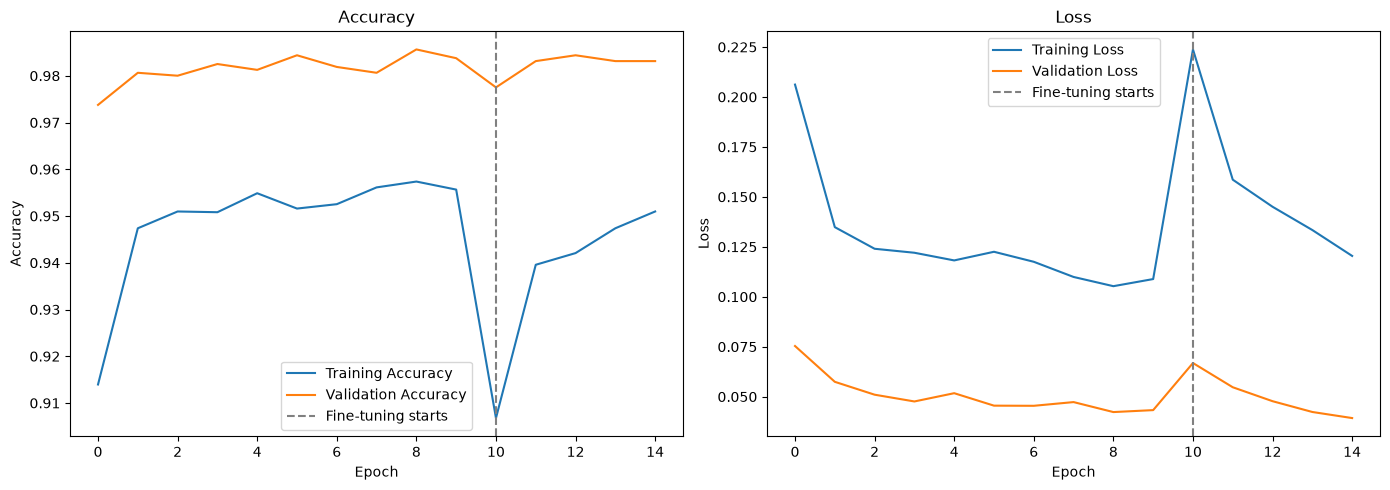

In [18]:
def merge_history(h1, h2, key):
    return h1.history[key] + h2.history[key]

acc = merge_history(history, history_fine, "accuracy")
val_acc = merge_history(history, history_fine, "val_accuracy")
loss = merge_history(history, history_fine, "loss")
val_loss = merge_history(history, history_fine, "val_loss")
switch_epoch = len(history.history["loss"])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(acc, label="Training Accuracy")
axes[0].plot(val_acc, label="Validation Accuracy")
axes[0].axvline(switch_epoch, linestyle="--", color="gray", label="Fine-tuning starts")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].set_title("Accuracy")
axes[0].legend()

axes[1].plot(loss, label="Training Loss")
axes[1].plot(val_loss, label="Validation Loss")
axes[1].axvline(switch_epoch, linestyle="--", color="gray", label="Fine-tuning starts")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].set_title("Loss")
axes[1].legend()

plt.tight_layout()
plt.show()

## 10. Final evaluation on the held-out test set

In [19]:
test_loss, test_accuracy = model.evaluate(test_ds)
print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

64/64 ━━━━━━━━━━━━━━━━━━━━ 27s 420ms/step - accuracy: 0.9842 - loss: 0.0398
Test Loss: 0.03984927758574486
Test Accuracy: 0.9841818809509277


64/64 ━━━━━━━━━━━━━━━━━━━━ 34s 485ms/step
              precision    recall  f1-score   support

        cats       0.99      0.98      0.98      1011
        dogs       0.98      0.99      0.98      1012

    accuracy                           0.98      2023
   macro avg       0.98      0.98      0.98      2023
weighted avg       0.98      0.98      0.98      2023



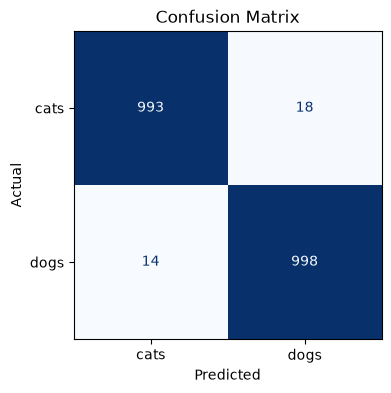

In [20]:
from sklearn.metrics import ConfusionMatrixDisplay

y_true = np.concatenate([y.numpy() for _, y in test_ds]).astype(int).flatten()
y_pred_prob = model.predict(test_ds).flatten()
y_pred = (y_pred_prob > 0.5).astype(int)

print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(5, 4))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap="Blues", ax=ax, colorbar=False)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Confusion Matrix")
plt.show()

## 11. Save the model

In [21]:
model.save("dog_cat_model.keras")
print("Model saved successfully!")

Model saved successfully!


## 12. Predict on a single image

Drop in any image path (a photo you have locally, or one from the test set) to see the
predicted label and confidence.

In [22]:
def predict_image(img_path, model=model, class_names=class_names, img_size=IMG_SIZE):
    img = tf.keras.utils.load_img(img_path, target_size=img_size)
    img_array = tf.keras.utils.img_to_array(img)
    img_array = tf.expand_dims(img_array, 0)  # add batch dimension

    prob = model.predict(img_array, verbose=0)[0][0]
    predicted_class = class_names[int(prob > 0.5)]
    confidence = prob if prob > 0.5 else 1 - prob

    plt.imshow(img)
    plt.axis("off")
    plt.title(f"{predicted_class} ({confidence:.1%} confidence)")
    plt.show()

    return predicted_class, float(confidence)

# Example usage:
# predict_image("/path/to/some/photo.jpg")